In [7]:
import joblib
from pathlib import Path
import subprocess, sys

try:
    ROOT = Path(subprocess.check_output(["git","rev-parse","--show-toplevel"], text=True).strip())
except Exception:
    ROOT = Path.cwd().resolve().parent  # experiments/ -> repo root

# Make repo packages (e.g., `pipeline`) importable for unpickling
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# (optional) pre-import the class’ module used in the pickle
# from pipeline.algo1 import Algo1Outputs

artifact = ROOT / "outputs" / "artifacts" / "algo1_outs_2025-05-22_1min_agreg.pkl"
outs = joblib.load(artifact)
print("Loaded:", artifact)

Loaded: /Users/167011/Documents/GitHub/deribit_market_model/outputs/artifacts/algo1_outs_2025-05-22_1min_agreg.pkl


In [8]:
from neural_sde.loss_jumps import likelihood_training_one_jump
import torch
torch.manual_seed(80085)
train_losses, test_losses, model, X_train = likelihood_training_one_jump(outs, n_epochs = 600, batch_size=256,
zero_drift=False, lr=5e-5)

Epoch 1/600  Train NLL: 1.1566e+02  Test NLL: 1.1916e+02
Epoch 2/600  Train NLL: 9.7626e+01  Test NLL: 1.0071e+02
Epoch 3/600  Train NLL: 8.1746e+01  Test NLL: 8.4433e+01
Epoch 4/600  Train NLL: 6.7841e+01  Test NLL: 7.0159e+01
Epoch 5/600  Train NLL: 5.5656e+01  Test NLL: 5.7650e+01
Epoch 6/600  Train NLL: 4.4927e+01  Test NLL: 4.6650e+01
Epoch 7/600  Train NLL: 3.5499e+01  Test NLL: 3.7002e+01
Epoch 8/600  Train NLL: 2.7349e+01  Test NLL: 2.8663e+01
Epoch 9/600  Train NLL: 2.0476e+01  Test NLL: 2.1611e+01
Epoch 10/600  Train NLL: 1.4814e+01  Test NLL: 1.5757e+01
Epoch 11/600  Train NLL: 1.0286e+01  Test NLL: 1.1018e+01
Epoch 12/600  Train NLL: 6.8642e+00  Test NLL: 7.3832e+00
Epoch 13/600  Train NLL: 4.4962e+00  Test NLL: 4.8374e+00
Epoch 14/600  Train NLL: 2.9290e+00  Test NLL: 3.1766e+00
Epoch 15/600  Train NLL: 2.1453e+00  Test NLL: 2.1642e+00
Epoch 16/600  Train NLL: 2.3979e+00  Test NLL: 2.1639e+00
Epoch 17/600  Train NLL: 2.3317e+00  Test NLL: 2.1168e+00
Epoch 18/600  Train NLL

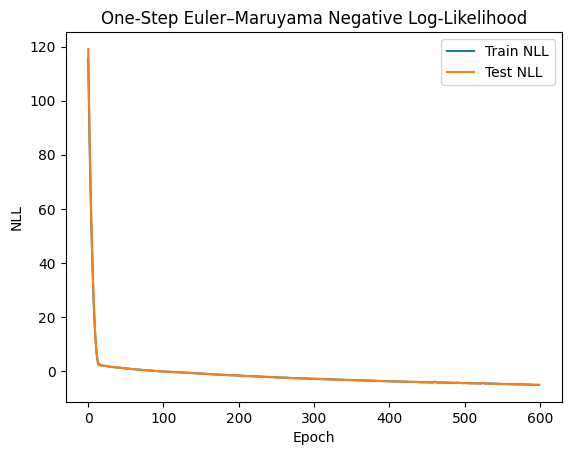

In [9]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(train_losses, label="Train NLL")
plt.plot(test_losses, label="Test NLL")
plt.title("One-Step Euler–Maruyama Negative Log-Likelihood")
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.legend()
plt.show()

In [10]:
# no filepath (run in notebook)
import numpy as np, torch
from neural_sde.loss import build_xi_training_data
from neural_sde.constraints import compute_factor_polytope_vertices
from neural_sde.loss_jumps import jump_mixture_nll_diag  # same kernel as training

X_tr, X_te, _ = build_xi_training_data(outs)
tt_tr = outs.C_train.index.values; tt_te = outs.C_test.index.values
sec_per_year = 1
dt_tr = (np.diff(tt_tr).astype('timedelta64[s]').astype(np.float64) / sec_per_year)
dt_te = (np.diff(tt_te).astype('timedelta64[s]').astype(np.float64) / sec_per_year)

Y0_tr = torch.from_numpy(X_tr[:-1]).float();  Y1_tr = torch.from_numpy(X_tr[1:]).float()
Y0_te = torch.from_numpy(X_te[:-1]).float();  Y1_te = torch.from_numpy(X_te[1:]).float()
DT_tr = torch.from_numpy(dt_tr[:Y0_tr.shape[0]]).float().unsqueeze(1)
DT_te = torch.from_numpy(dt_te[:Y0_te.shape[0]]).float().unsqueeze(1)

poly = compute_factor_polytope_vertices(outs, xi_builder=None, k_box=6.0, verbose=False)
H_np, h_np = poly["H"], poly["h"]

with torch.no_grad():
    nll_tr = jump_mixture_nll_diag(Y0_tr, Y1_tr, DT_tr, model,
                                   H=H_np, h=h_np, use_diffusion_shrink=True).mean().item()
    nll_te = jump_mixture_nll_diag(Y0_te, Y1_te, DT_te, model,
                                   H=H_np, h=h_np, use_diffusion_shrink=True).mean().item()
print("dt median train|test:", float(np.median(dt_tr)), float(np.median(dt_te)))
print("std(|ΔX|) train|test:", float(np.std(X_tr[1:]-X_tr[:-1])), float(np.std(X_te[1:]-X_te[:-1])))
print("Recomputed NLL train|test (same kernel):", nll_tr, nll_te)

dt median train|test: 60.0 60.0
std(|ΔX|) train|test: 0.016355209781700693 0.01430366219113192
Recomputed NLL train|test (same kernel): -5.128176212310791 -5.136120796203613


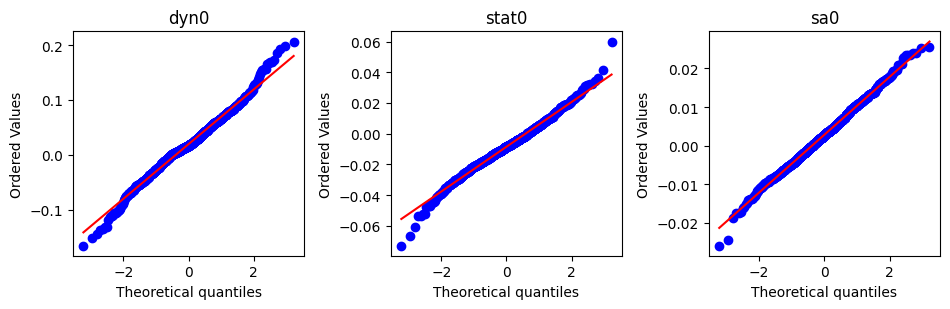

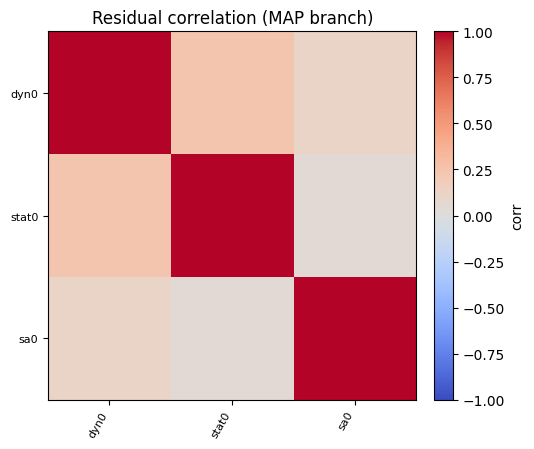

Mean posterior jump prob: 0.4965
Frac MAP=jump: 0.0000


In [12]:
# QQ plots and residual correlations for the trained jump model
# Uses posterior MAP component: no‑jump residual z0 or one‑jump residual z1

import numpy as np
import pandas as pd
import torch
from scipy import stats
import matplotlib.pyplot as plt

from neural_sde.loss import build_xi_training_data  # -> [neural_sde.loss.build_xi_training_data](neural_sde/loss.py)

# 1) Build train pairs and dt aligned with training
X_train, _, names = build_xi_training_data(outs)  # (T, p)
tt = pd.to_datetime(outs.C_train.index.values)

# Use seconds (matches the pattern used in several jump notebooks)
sec_per_year = 1
dt_np = np.asarray((tt[1:] - tt[:-1]).astype('timedelta64[s]'), dtype=np.int64) / sec_per_year

# Align lengths
L = min(len(dt_np), X_train.shape[0]-1)
Y0 = torch.from_numpy(X_train[:L]).float()
Y1 = torch.from_numpy(X_train[1:L+1]).float()
dt = torch.from_numpy(dt_np[:L].copy()).float().unsqueeze(1).clamp_min(1e-12)

device = next(model.parameters()).device
Y0 = Y0.to(device); Y1 = Y1.to(device); dt = dt.to(device)

@torch.no_grad()
def _gauss_logpdf_diag(x, mean, var):
    # x, mean, var: [B,p]
    return -0.5 * (((x - mean)**2) / var + torch.log(2*np.pi*var)).sum(dim=-1)  # [B]

@torch.no_grad()
def compute_jump_residuals_MAP(model, Y0, Y1, dt):
    # Model eval
    mu  = model.f(0.0, Y0)                       # [B,p]
    sig = model.g(0.0, Y0).clamp_min(1e-9)       # [B,p]
    lam, mJ, SJ_L = model.jump_head(Y0)          # lam:[B], mJ:[B,p], SJ_L:[B,p,p]
    sJ  = torch.diagonal(SJ_L, dim1=-2, dim2=-1) # [B,p]

    dts = dt.view(-1, 1)                         # [B,1]
    md0 = Y0 + mu * dts                          # [B,p]
    v0  = (sig**2) * dts                         # [B,p]

    # One‑jump branch stats (single jump across all dims with diag Σ_J)
    md1 = md0 + mJ                                # [B,p]
    v1  = v0 + (sJ**2)                            # [B,p]

    # Mixture weights using Poisson(λΔ) up to 1‑jump
    ldt = (lam * dt.view(-1))                     # [B]
    log_p0 = -ldt                                 # log e^{-λΔ}
    log_p1 = torch.log(ldt.clamp_min(1e-12)) - ldt

    # Vector likelihoods (indep dims given component)
    loglik0 = log_p0 + _gauss_logpdf_diag(Y1, md0, v0)  # [B]
    loglik1 = log_p1 + _gauss_logpdf_diag(Y1, md1, v1)  # [B]

    # Responsibilities and MAP assignment
    m = torch.stack([loglik0, loglik1], dim=1)          # [B,2]
    m_max = m.max(dim=1, keepdim=True).values
    post = torch.softmax(m - m_max, dim=1)              # [B,2]
    r0, r1 = post[:, 0:1], post[:, 1:2]                # [B,1]
    is_jump = (r1 > 0.5).float()                       # MAP

    # Standardized residuals per branch
    z0 = (Y1 - md0) / torch.sqrt(v0)                   # [B,p]
    z1 = (Y1 - md1) / torch.sqrt(v1)                   # [B,p]
    z  = is_jump * z1 + (1.0 - is_jump) * z0           # MAP residuals

    return z.cpu().numpy(), r1.squeeze(1).cpu().numpy()


resid_map, jump_prob = compute_jump_residuals_MAP(model, Y0, Y1, dt)  # resid_map: (B,p)

# 2) QQ plots per factor
d = resid_map.shape[1]
cols = 3
rows = int(np.ceil(d / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*3.2))
axes = axes.ravel()

labels = names if (isinstance(names, (list, tuple)) and len(names)==d) else [f"f{j}" for j in range(d)]
for j in range(d):
    stats.probplot(resid_map[:, j], dist="norm", plot=axes[j])
    axes[j].set_title(labels[j])

for k in range(d, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

# 3) Residual correlation matrix (Pearson)
R = np.asarray(resid_map, float)  # (B,d)
corr = np.corrcoef(R, rowvar=False)  # (d,d)

plt.figure(figsize=(5.5, 4.6))
im = plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04, label="corr")
plt.xticks(range(d), labels, rotation=60, ha="right", fontsize=8)
plt.yticks(range(d), labels, fontsize=8)
plt.title("Residual correlation (MAP branch)")
plt.tight_layout()
plt.show()

# (Optional) quick diagnostics
print(f"Mean posterior jump prob: {jump_prob.mean():.4f}")
print(f"Frac MAP=jump: {(jump_prob>0.5).mean():.4f}")

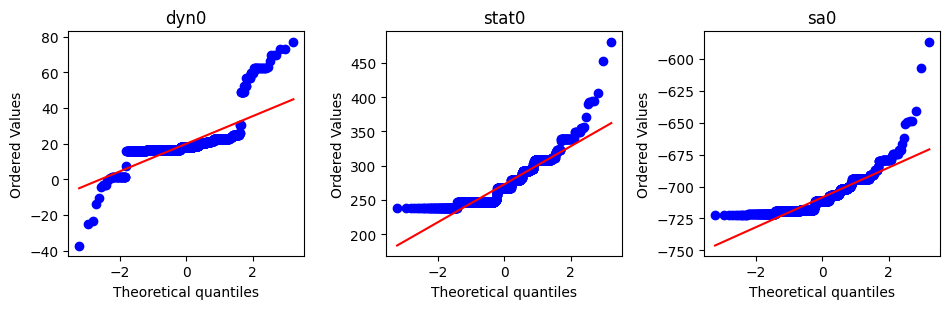

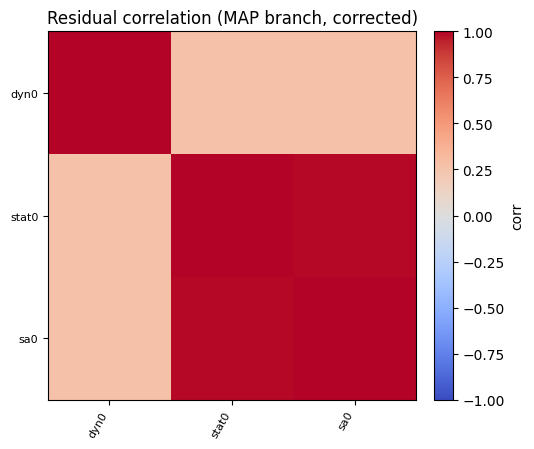

Mean posterior jump prob (corrected): 1.0000
Frac MAP=jump (corrected): 1.0000


In [6]:
# End-to-end: corrected residuals with drift BC, shrunk diffusion, shrunk jumps
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy import stats

from neural_sde.loss import build_xi_training_data
from neural_sde.constraints import compute_factor_polytope_vertices, shrink_matrix_and_diag
try:
    # internal helper name in this repo
    from neural_sde.constraints import _apply_boundary_correction as apply_bc
except Exception:
    apply_bc = None

device = next(model.parameters()).device

# 1) Build train pairs and dt with same time scale as training (seconds-as-years)
X_train, _, names = build_xi_training_data(outs)  # (T, p)
tt = pd.to_datetime(outs.C_train.index.values).values
dt_np = (tt[1:] - tt[:-1]).astype('timedelta64[s]').astype(np.int64).astype(np.float32)

L = min(len(dt_np), X_train.shape[0]-1)
Y0 = torch.from_numpy(X_train[:L]).float().to(device)
Y1 = torch.from_numpy(X_train[1:L+1]).float().to(device)
dt = torch.from_numpy(dt_np[:L].copy()).float().unsqueeze(1).clamp_min(1e-12).to(device)
t_idx = torch.arange(L, device=device)  # align caches to these rows

# 2) Polytope and per-step shrink
poly = compute_factor_polytope_vertices(outs, xi_builder=None, k_box=6.0, verbose=False)
H_np, h_np = poly["H"], poly["h"]  # H z >= h
H_t = torch.from_numpy(H_np).float().to(device)           # [K,p]
h_t = torch.from_numpy(h_np).float().to(device)           # [K]

@torch.no_grad()
def gauss_logpdf_diag(x, mean, var):
    return -0.5 * (((x - mean)**2) / (var + 1e-18) + torch.log(2*np.pi*(var + 1e-18))).sum(dim=-1)

@torch.no_grad()
def compute_jump_residuals_MAP_corrected(model, Y0, Y1, dt, H_t, h_t,
                                         use_diffusion_shrink=True,
                                         use_drift_bc=True,
                                         use_jump_shrink=True,
                                         bc_lambda=1.0, bc_cap=5.0, bc_eps_floor=1e-8, bc_epsmu_cutoff=1e-3,
                                         jump_alpha_lambda=1.0, jump_alpha_cov=1.0, jump_alpha_mean=0.5,
                                         s_floor=0.15,                   # NEW: don’t shrink below this
                                         rel_sJ_floor=0.10,              # NEW: sJ floor relative to sig_eff
                                         var_floor_quantile=0.05,        # NEW: add scalar var floor
                                         use_mixture_residual=True):     # NEW: prefer r-weighted residuals
    B, p = Y0.shape
    dts = dt.view(-1, 1)

    # Base model eval
    mu  = model.f(0.0, Y0)
    sig = model.g(0.0, Y0).clamp_min(1e-9)
    lam, mJ, SJ_L = model.jump_head(Y0)
    sJ  = torch.diagonal(SJ_L, dim1=-2, dim2=-1)

    # Drift BC
    if use_drift_bc and (apply_bc is not None):
        with torch.no_grad():
            H_norm = H_t / (H_t.norm(dim=1, keepdim=True) + 1e-12)
            Hy = (Y0 @ H_t.t())
            epsmu = torch.relu(h_t.unsqueeze(0) - Hy)
            corr_dirs = H_norm.unsqueeze(0).expand(B, -1, -1).contiguous()
        try:
            mu = apply_bc(mu, t_idx, corr_dirs, epsmu,
                          bc_lambda=bc_lambda, bc_eps_floor=bc_eps_floor, bc_cap=bc_cap,
                          bc_epsmu_cutoff=bc_epsmu_cutoff, device=Y0.device)
        except Exception as e:
            print(f"[warn] drift BC skipped: {e}")

    # Diffusion shrink with floor
    if use_diffusion_shrink:
        s = shrink_matrix_and_diag(Y0, H_t, h_t, mode="diag")
        s = torch.clamp(s, min=s_floor)            # floor
        sig_eff = s * sig
    else:
        s = torch.ones_like(sig)
        sig_eff = sig

    # Jump shrink with floors
    if use_jump_shrink:
        s_min = s.min(dim=1, keepdim=True).values
        lam_eff = lam * torch.clamp(s_min.squeeze(1), 0.0, 1.0).pow(jump_alpha_lambda)
        mJ_eff  = mJ * torch.clamp(s, 0.0, 1.0).pow(jump_alpha_mean)
        sJ_eff  = sJ * torch.clamp(s, 0.0, 1.0).pow(jump_alpha_cov)
    else:
        lam_eff, mJ_eff, sJ_eff = lam, mJ, sJ

    # Enforce a relative variance floor on jumps
    sJ_eff = torch.maximum(sJ_eff, rel_sJ_floor * sig_eff)

    # Component stats
    md0 = Y0 + mu * dts
    v0  = (sig_eff**2) * dts
    md1 = md0 + mJ_eff
    v1  = v0 + (sJ_eff**2)

    # Add scalar variance floor from a lower quantile of baseline step variance
    base_var = (sig**2) * dts
    v_floor = torch.quantile(base_var.view(-1), q=var_floor_quantile).clamp_min(1e-14)
    v0 = v0 + v_floor
    v1 = v1 + v_floor

    # Mixture weights (0/1 truncation)
    ldt = (lam_eff * dt.view(-1)).clamp_min(0.0)
    log_p0 = -ldt
    log_p1 = torch.log(ldt.clamp_min(1e-12)) - ldt

    # Likelihoods
    def gauss_logpdf_diag(x, mean, var):
        return -0.5 * (((x - mean)**2) / (var + 1e-18) + torch.log(2*np.pi*(var + 1e-18))).sum(dim=-1)

    loglik0 = log_p0 + gauss_logpdf_diag(Y1, md0, v0)
    loglik1 = log_p1 + gauss_logpdf_diag(Y1, md1, v1)
    m = torch.stack([loglik0, loglik1], dim=1)
    post = torch.softmax(m - m.max(dim=1, keepdim=True).values, dim=1)
    r1 = post[:, 1:2]

    # Residuals
    z0 = (Y1 - md0) / torch.sqrt(v0 + 1e-18)
    z1 = (Y1 - md1) / torch.sqrt(v1 + 1e-18)
    if use_mixture_residual:
        z = (1.0 - r1) * z0 + r1 * z1     # smoother than hard MAP
    else:
        is_jump = (r1 > 0.5).float()
        z = is_jump * z1 + (1.0 - is_jump) * z0

    return z.cpu().numpy(), r1.squeeze(1).cpu().numpy()

# 3) Compute corrected residuals
resid_map, jump_prob = compute_jump_residuals_MAP_corrected(
    model, Y0, Y1, dt, H_t, h_t,
    use_diffusion_shrink=True, use_drift_bc=True, use_jump_shrink=True,
    bc_lambda=1.0, bc_cap=5.0, bc_eps_floor=1e-8, bc_epsmu_cutoff=1e-3,
    jump_alpha_lambda=1.0, jump_alpha_cov=1.0, jump_alpha_mean=0.5
)

# 4) QQ plots
d = resid_map.shape[1]
cols = 3
rows = int(np.ceil(d / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*3.2))
axes = axes.ravel()
labels = names if (isinstance(names, (list, tuple)) and len(names)==d) else [f"f{j}" for j in range(d)]
for j in range(d):
    stats.probplot(resid_map[:, j], dist="norm", plot=axes[j])
    axes[j].set_title(labels[j])
for k in range(d, len(axes)):
    axes[k].axis("off")
plt.tight_layout(); plt.show()

# 5) Residual correlation heatmap
R = np.asarray(resid_map, float)
corr = np.corrcoef(R, rowvar=False)
plt.figure(figsize=(5.5, 4.6))
im = plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04, label="corr")
plt.xticks(range(d), labels, rotation=60, ha="right", fontsize=8)
plt.yticks(range(d), labels, fontsize=8)
plt.title("Residual correlation (MAP branch, corrected)")
plt.tight_layout(); plt.show()

print(f"Mean posterior jump prob (corrected): {jump_prob.mean():.4f}")
print(f"Frac MAP=jump (corrected): {(jump_prob>0.5).mean():.4f}")

In [8]:
# python
with torch.no_grad():
    mu  = model.f(0.0, Y0)
    sig = model.g(0.0, Y0).clamp_min(1e-9)
    lam, mJ, SJ_L = model.jump_head(Y0)
ldt = (lam * dt.view(-1)).detach().cpu().numpy()
print("Δ (median seconds) =", float(dt.median().cpu()))
print("λΔ stats mean|med|p90|p99 =", ldt.mean(), np.median(ldt), *np.quantile(ldt, [0.9,0.99]))
print("σ median per-dim =", torch.median(sig, dim=0).values.cpu().numpy())
print("sJ median per-dim =", torch.median(torch.diagonal(SJ_L, -2, -1), dim=0).values.cpu().numpy())

Δ (median seconds) = 60.0
λΔ stats mean|med|p90|p99 = 0.050000004 0.05 0.05000000074505806 0.05000000074505806
σ median per-dim = [0.04992293 0.07469197 0.05937411]
sJ median per-dim = [0.]


In [8]:
# no filepath (run in notebook)
with torch.no_grad():
    lam, mJ, SJ_L = model.jump_head(Y0)
print("mJ median per-dim =", torch.median(mJ, dim=0).values.cpu().numpy())

mJ median per-dim = [ 9.3113398e-05 -1.6028993e-04  3.0750874e-05]


In [7]:
# Compare mJ to diffusion step std and to actual step sizes
with torch.no_grad():
    mu  = model.f(0.0, Y0)
    sig = model.g(0.0, Y0).clamp_min(1e-9)
    lam, mJ, SJ_L = model.jump_head(Y0)

dts = dt.view(-1,1)
diff_step_std = (sig * torch.sqrt(dts)).median(dim=0).values.cpu().numpy()
mJ_med = torch.median(mJ, dim=0).values.cpu().numpy()

import numpy as np
X0 = Y0.detach().cpu().numpy()
X1 = Y1.detach().cpu().numpy()
dx = X1 - X0
dx_med = np.median(np.abs(dx), axis=0)

print("diffusion step std (median):", diff_step_std)
print("mJ median per-dim:", mJ_med)
print("mJ / diffusion_std:", mJ_med / (diff_step_std + 1e-12))
print("|ΔX| median per-dim:", dx_med)

diffusion step std (median): [0.40039262 0.59991133 0.47730654]
mJ median per-dim: [ 9.3113398e-05 -1.6028993e-04  3.0750874e-05]
mJ / diffusion_std: [ 2.3255523e-04 -2.6718937e-04  6.4425840e-05]
|ΔX| median per-dim: [0.01284529 0.00579348 0.00156998]


In [6]:
# no filepath (run in notebook)
import torch
from neural_sde.constraints import compute_factor_polytope_vertices, shrink_matrix_and_diag

poly = compute_factor_polytope_vertices(outs, xi_builder=None, k_box=6.0, verbose=False)
H_np, h_np = poly["H"], poly["h"]
H_t = torch.from_numpy(H_np).float().to(device)
h_t = torch.from_numpy(h_np).float().to(device)

with torch.no_grad():
    sig = model.g(0.0, Y0).clamp_min(1e-9)          # raw σ
    s   = shrink_matrix_and_diag(Y0, H_t, h_t, mode="diag")  # per-dim s∈[0,1]
    sig_eff = (s * sig)
    dts = dt.view(-1,1)
    print("effective diffusion step std (median):", torch.median(sig_eff*torch.sqrt(dts), dim=0).values.cpu().numpy())

effective diffusion step std (median): [1.03846155e-02 8.76016729e-03 2.78901962e-06]
